In [7]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_new = pd.read_csv("Final_Data.csv")
df_new

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,Crime_Rate_Index,...,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price,Renovation_Status_Yes,Property_Type_Independent House,Property_Type_Villa
0,2684.821829,5,5,2,2018,7,3776.225833,33.354414,8,35.239294,...,4,5,8,51.585174,42.269855,51.872234,1.203248e+07,True,True,False
1,1772.507662,1,1,1,1970,55,3343.248191,21.896193,5,63.487365,...,3,5,8,36.729241,66.331214,66.489083,7.425842e+06,False,False,False
2,1655.959623,2,1,1,2015,10,2856.909759,25.358405,2,83.749235,...,3,5,10,20.020779,79.023068,68.119671,5.734560e+06,False,False,False
3,1655.979127,1,1,1,1976,49,2998.753552,22.062582,6,55.247941,...,9,2,4,40.894197,53.745498,60.449037,8.258959e+06,True,False,False
4,3153.592273,6,5,2,2002,23,4064.463530,35.406036,10,20.723259,...,10,10,9,91.836212,19.668196,53.206428,1.445879e+07,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8705,2302.741825,2,2,1,1994,31,3766.541599,10.708116,9,30.634170,...,7,6,2,72.799026,36.744778,43.506769,1.173157e+07,False,False,True
8706,1373.561786,3,3,2,1994,31,2271.349068,11.949866,4,58.222542,...,9,3,8,25.805114,89.150722,66.396883,6.458641e+06,False,False,True
8707,1191.319333,2,2,2,2022,3,2748.265662,23.944225,2,84.525293,...,10,4,8,0.000000,91.177488,76.934267,4.891362e+06,False,True,False
8708,2811.384485,6,5,1,1970,55,4906.370154,7.170758,8,35.927063,...,1,8,7,54.362379,47.010666,53.486149,1.353664e+07,False,False,True


In [9]:
x = df_new.drop('Price' , axis=1)
y = df_new['Price']

In [10]:
x_train  , x_test , y_train , y_test = train_test_split( x , y , test_size = 0.4 , random_state = 42)

In [11]:
x_train , x_test , y_train , y_test

(      Property_Area  Bedrooms  Bathrooms  Floors  Year_Built  Property_Age  \
 6478    1519.810846         3          2       2        1993            32   
 4301    2205.243515         1          1       1        2002            23   
 7378     993.533878         2          1       2        2016             9   
 524     1377.378030         3          2       2        2002            23   
 3955    1069.276636         2          2       1        2024             1   
 ...             ...       ...        ...     ...         ...           ...   
 5734    1218.018143         1          1       1        2021             4   
 5191    1402.159225         2          2       2        1998            27   
 5390    1485.244890         1          1       1        2007            18   
 860     2708.646550         5          5       1        2000            25   
 7270    2611.447398         4          3       1        2010            15   
 
          Lot_Size  Distance_to_City_Center  Neigh

In [12]:
#Although all Columns are Already Numeric , Dummy Columns (Encoded Columns) are NOT to be Scaled

num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if x_train[col].nunique() > 2]
num_cols

['Property_Area',
 'Bedrooms',
 'Bathrooms',
 'Floors',
 'Year_Built',
 'Property_Age',
 'Lot_Size',
 'Distance_to_City_Center',
 'Neighborhood_Quality_Score',
 'Crime_Rate_Index',
 'Nearby_School_Rating',
 'Hospital_Proximity_km',
 'Shopping_Center_Proximity_km',
 'Public_Transport_Accessibility',
 'Construction_Quality_Rating',
 'Energy_Efficiency_Score',
 'Water_Supply_Reliability',
 'Electricity_Supply_Reliability',
 'Internet_Availability_Score',
 'Green_Space_Availability_Index',
 'Flood_Risk_Index',
 'Noise_Pollution_Level']

In [16]:
model = RandomForestRegressor(random_state=42)

In [17]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [26]:
search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs = -1 , 
    random_state=42
)

In [27]:
search.fit(x_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [28]:
y_pred= best_model.predict(x_test)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

mean_y = y.mean()

print("Mean of target:", mean_y)
print("RMSE %:", (rmse / mean_y) * 100)
print("MAE %:", (mae / mean_y) * 100)

print("Min:", y.min())
print("Max:", y.max())
print("Mean:", y.mean())

RMSE: 1082487.4847186934
MAE: 851878.5191690706
Mean of target: 8514450.099310054
RMSE %: 12.71353372317503
MAE %: 10.005091453153273
Min: 500000.0
Max: 20483881.091685265
Mean: 8514450.099310054


In [30]:
r2 = r2_score(y_test , y_pred) 
print("R2 Score : " , r2)

R2 Score :  0.9341565292525427


In [32]:
y_train_pred = best_model.predict(x_train)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9870706331503561
Test R2: 0.9341565292525427


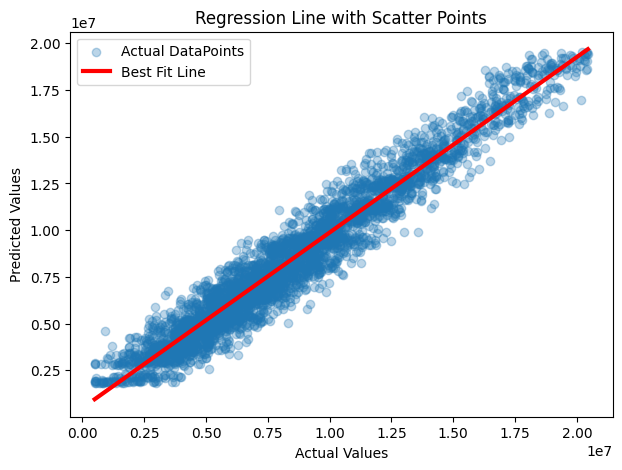

In [30]:
plt.figure(figsize=(7,5))

# Scatter points
plt.scatter(y_test, y_pred, alpha=0.3 , label='Actual DataPoints')

# Create regression line
m, b = np.polyfit(y_test, y_pred, 1)
line = m * y_test + b

# Sort values for smooth line
sorted_idx = np.argsort(y_test)

plt.plot(y_test.iloc[sorted_idx], line.iloc[sorted_idx] , color= 'red' , linewidth = 3 , label='Best Fit Line')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Regression Line with Scatter Points")
plt.legend()
plt.show()

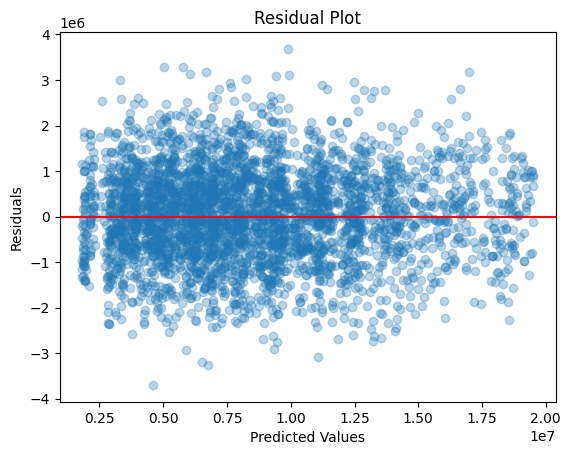

In [31]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

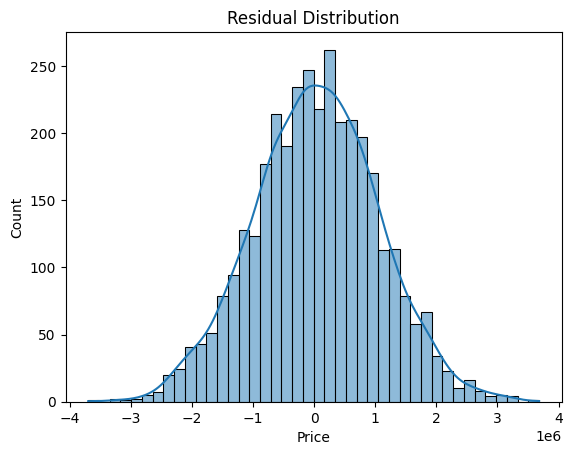

In [32]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()